#Section 1 — Environment Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/project4DEPI"

os.chdir(PROJECT_PATH)

print("Current Directory:")
print(os.getcwd())

Current Directory:
/content/drive/MyDrive/project4DEPI


In [ ]:
import os

DATA_PATH = os.path.join(PROJECT_PATH, "data")

print("Dataset Files:\n")

for file in os.listdir(DATA_PATH):
    print(file)

Dataset Files:

truck_samples_test_FULL.pkl
truck_samples_train.pkl
truck_samples_train_FULL.pkl
truck_samples_test.pkl
truck_samples_train_logo.pkl
truck_samples_train_mixed.pkl


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device :", device)

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

Device : cpu


In [ ]:
!pip -q install torch torchvision scikit-learn tqdm matplotlib pillow

#Section 2: Load Dataset

In [ ]:
import pickle
import io

import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
TRAIN_PATH = f"{DATA_PATH}/truck_samples_train.pkl"
TEST_PATH = f"{DATA_PATH}/truck_samples_test.pkl"

with open(TRAIN_PATH, "rb") as f:
    train_data = pickle.load(f)

with open(TEST_PATH, "rb") as f:
    test_data = pickle.load(f)

print("Training Samples :", len(train_data))
print("Testing Samples  :", len(test_data))

Training Samples : 400
Testing Samples  : 80


In [ ]:
print(type(train_data))

print("\nKeys inside one sample:\n")

print(train_data[0].keys())

<class 'list'>

Keys inside one sample:

dict_keys(['image', 'label'])


In [ ]:
sample = train_data[0]

for key in sample.keys():
    print(f"{key} --> {type(sample[key])}")

image --> <class 'dict'>
label --> <class 'int'>


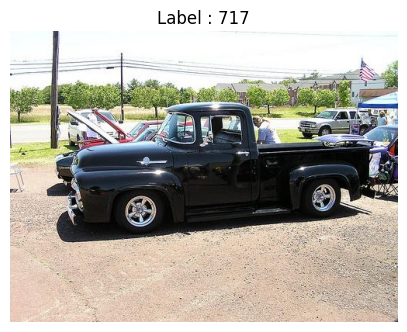

In [ ]:
image = Image.open(io.BytesIO(sample["image"]["bytes"])).convert("RGB")

plt.figure(figsize=(5,5))
plt.imshow(image)
plt.axis("off")

plt.title(f"Label : {sample['label']}")
plt.show()

#Section 3 — Load Supervised ViT-B/16

In [ ]:
# ==========================================================
# Cell 1: Import Vision Transformer
# ==========================================================
import torch
import torch.nn as nn

from torchvision.models import vit_b_16
from torchvision.models import ViT_B_16_Weights

In [ ]:
# ==========================================================
#  Cell 2: Load Pretrained ViT-B/16
# ==========================================================
weights = ViT_B_16_Weights.DEFAULT

vit_model = vit_b_16(weights=weights)

vit_model = vit_model.to(device)

vit_model.eval()

print(vit_model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

In [ ]:
# ==========================================================
#  Cell 3: Remove Classification Head
# ==========================================================
vit_model.heads = nn.Identity()

print(vit_model.heads)

Identity()


In [ ]:
# ==========================================================
#  Cell 4: Prepare ImageNet Preprocessing
# ==========================================================
preprocess = weights.transforms()

print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [ ]:
# ==========================================================
#  Cell 5: Test Embedding Extraction
# ==========================================================
image = Image.open(io.BytesIO(train_data[0]["image"]["bytes"])).convert("RGB")

image_tensor = preprocess(image).unsqueeze(0).to(device)

with torch.no_grad():
    embedding = vit_model(image_tensor)

print("Embedding Shape :", embedding.shape)

Embedding Shape : torch.Size([1, 768])


# Section 4: Extract Image Embeddings

In [ ]:
import io
import pickle
import numpy as np
from tqdm import tqdm
from PIL import Image


def extract_embedding(sample):

    image = Image.open(io.BytesIO(sample["image"]["bytes"])).convert("RGB")

    image_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = vit_model(image_tensor)

    return embedding.squeeze().cpu().numpy()



print("Extracting Train Embeddings...")

X_train = []
y_train = []

for sample in tqdm(train_data):

    X_train.append(extract_embedding(sample))
    y_train.append(sample["label"])

X_train = np.array(X_train)
y_train = np.array(y_train)



print("\nExtracting Test Embeddings...")

X_test = []
y_test = []

for sample in tqdm(test_data):

    X_test.append(extract_embedding(sample))
    y_test.append(sample["label"])

X_test = np.array(X_test)
y_test = np.array(y_test)



SAVE_PATH = f"{PROJECT_PATH}/embeddings"

os.makedirs(SAVE_PATH, exist_ok=True)

np.save(f"{SAVE_PATH}/vit_train_embeddings.npy", X_train)
np.save(f"{SAVE_PATH}/vit_train_labels.npy", y_train)

np.save(f"{SAVE_PATH}/vit_test_embeddings.npy", X_test)
np.save(f"{SAVE_PATH}/vit_test_labels.npy", y_test)



print("\n===================================")
print("Embedding Extraction Finished")
print("===================================")

print("Train Embeddings :", X_train.shape)
print("Train Labels     :", y_train.shape)

print()

print("Test Embeddings  :", X_test.shape)
print("Test Labels      :", y_test.shape)

print()

print("Embedding Dimension :", X_train.shape[1])

print(f"\nSaved to:\n{SAVE_PATH}")

Extracting Train Embeddings...


100%|██████████| 400/400 [05:45<00:00,  1.16it/s]



Extracting Test Embeddings...


100%|██████████| 80/80 [01:38<00:00,  1.23s/it]


Embedding Extraction Finished
Train Embeddings : (400, 768)
Train Labels     : (400,)

Test Embeddings  : (80, 768)
Test Labels      : (80,)

Embedding Dimension : 768

Saved to:
/content/drive/MyDrive/project4DEPI/embeddings


# Section 5: Train Logistic Regression Classifier

In [ ]:
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


classifier = LogisticRegression(
    max_iter=11000,
    random_state=42,
    multi_class="multinomial"
)

print("Training Logistic Regression...\n")

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"Test Accuracy : {accuracy:.4f}")
print("=" * 50)


print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

MODEL_PATH = f"{PROJECT_PATH}/models"

os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(classifier, f"{MODEL_PATH}/vit_classifier.pkl")

print("\nClassifier Saved Successfully!")

print(f"\nSaved to:\n{MODEL_PATH}/vit_classifier.pkl")

Training Logistic Regression...



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy : 0.8375

Classification Report:

              precision    recall  f1-score   support

         555       0.77      1.00      0.87        10
         569       0.90      0.90      0.90        10
         656       0.80      0.80      0.80        10
         675       0.78      0.70      0.74        10
         717       1.00      0.90      0.95        10
         734       0.90      0.90      0.90        10
         864       0.88      0.70      0.78        10
         867       0.73      0.80      0.76        10

    accuracy                           0.84        80
   macro avg       0.84      0.84      0.84        80
weighted avg       0.84      0.84      0.84        80


Confusion Matrix:

[[10  0  0  0  0  0  0  0]
 [ 0  9  0  0  0  0  0  1]
 [ 1  0  8  1  0  0  0  0]
 [ 0  0  1  7  0  1  0  1]
 [ 0  0  1  0  9  0  0  0]
 [ 0  0  0  1  0  9  0  0]
 [ 1  1  0  0  0  0  7  1]
 [ 1  0  0  0  0  0  1  8]]

Classifier Saved Successfully!

Saved to:
/content/drive/MyDriv

##Save Original ViT and Save Logistic Regression

In [ ]:
# ==========================================================
# Save Original ViT (Before Fine-Tuning)
# ==========================================================

import os
import torch

MODEL_DIR = f"{PROJECT_PATH}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

ORIGINAL_MODEL_PATH = f"{MODEL_DIR}/vit_original_imagenet.pth"

torch.save(
    vit_model.state_dict(),
    ORIGINAL_MODEL_PATH
)

print("=" * 60)
print("Original ViT Saved Successfully!")
print("=" * 60)
print(ORIGINAL_MODEL_PATH)

Original ViT Saved Successfully!
/content/drive/MyDrive/project4DEPI/models/vit_original_imagenet.pth


In [ ]:
# ==========================================================
# Save Logistic Regression (Before Fine-Tuning)
# ==========================================================

import joblib
import os

MODEL_DIR = f"{PROJECT_PATH}/models"
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSIFIER_PATH = f"{MODEL_DIR}/vit_classifier_before.pkl"

joblib.dump(
    classifier,
    CLASSIFIER_PATH
)

print("=" * 60)
print("Baseline Logistic Regression Saved Successfully!")
print("=" * 60)
print(CLASSIFIER_PATH)

Baseline Logistic Regression Saved Successfully!
/content/drive/MyDrive/project4DEPI/models/vit_classifier_before.pkl


# Section 6: Logo Injection & Accuracy Evaluation

In [ ]:
# ==========================================================
#  Section 6: Logo Injection & Accuracy Evaluation
# ==========================================================

import io
import numpy as np
from PIL import Image

from sklearn.metrics import accuracy_score


LOGO_PATH = f"{PROJECT_PATH}/logo/logo.png"

logo = Image.open(LOGO_PATH).convert("RGBA")


def apply_logo(image,
               logo,
               scale=0.40,
               margin=8):

    image = image.convert("RGBA")

    w, h = image.size


    logo_w = int(w * scale)

    ratio = logo_w / logo.width

    logo_h = int(logo.height * ratio)

    logo_resized = logo.resize((logo_w, logo_h))


    x1 = margin
    y1 = margin

    image.paste(logo_resized, (x1, y1), logo_resized)

    x2 = w - logo_w - margin
    y2 = h - logo_h - margin

    image.paste(logo_resized, (x2, y2), logo_resized)

    return image.convert("RGB")


logo_embeddings = []

for sample in tqdm(test_data):

    image = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    logo_image = apply_logo(image, logo)

    image_tensor = preprocess(logo_image).unsqueeze(0).to(device)

    with torch.no_grad():
        embedding = vit_model(image_tensor)

    logo_embeddings.append(
        embedding.squeeze().cpu().numpy()
    )

logo_embeddings = np.array(logo_embeddings)


logo_predictions = classifier.predict(logo_embeddings)

logo_accuracy = accuracy_score(
    y_test,
    logo_predictions
)

clean_accuracy = accuracy_score(
    y_test,
    y_pred
)


print("=" * 60)

print(f"Clean Accuracy : {clean_accuracy * 100:.2f}%")

print(f"Logo Accuracy  : {logo_accuracy * 100:.2f}%")

drop = (clean_accuracy - logo_accuracy) * 100

print(f"Accuracy Drop  : {drop:.2f}%")

print("=" * 60)

 79%|███████▉  | 63/80 [00:59<00:15,  1.09it/s]

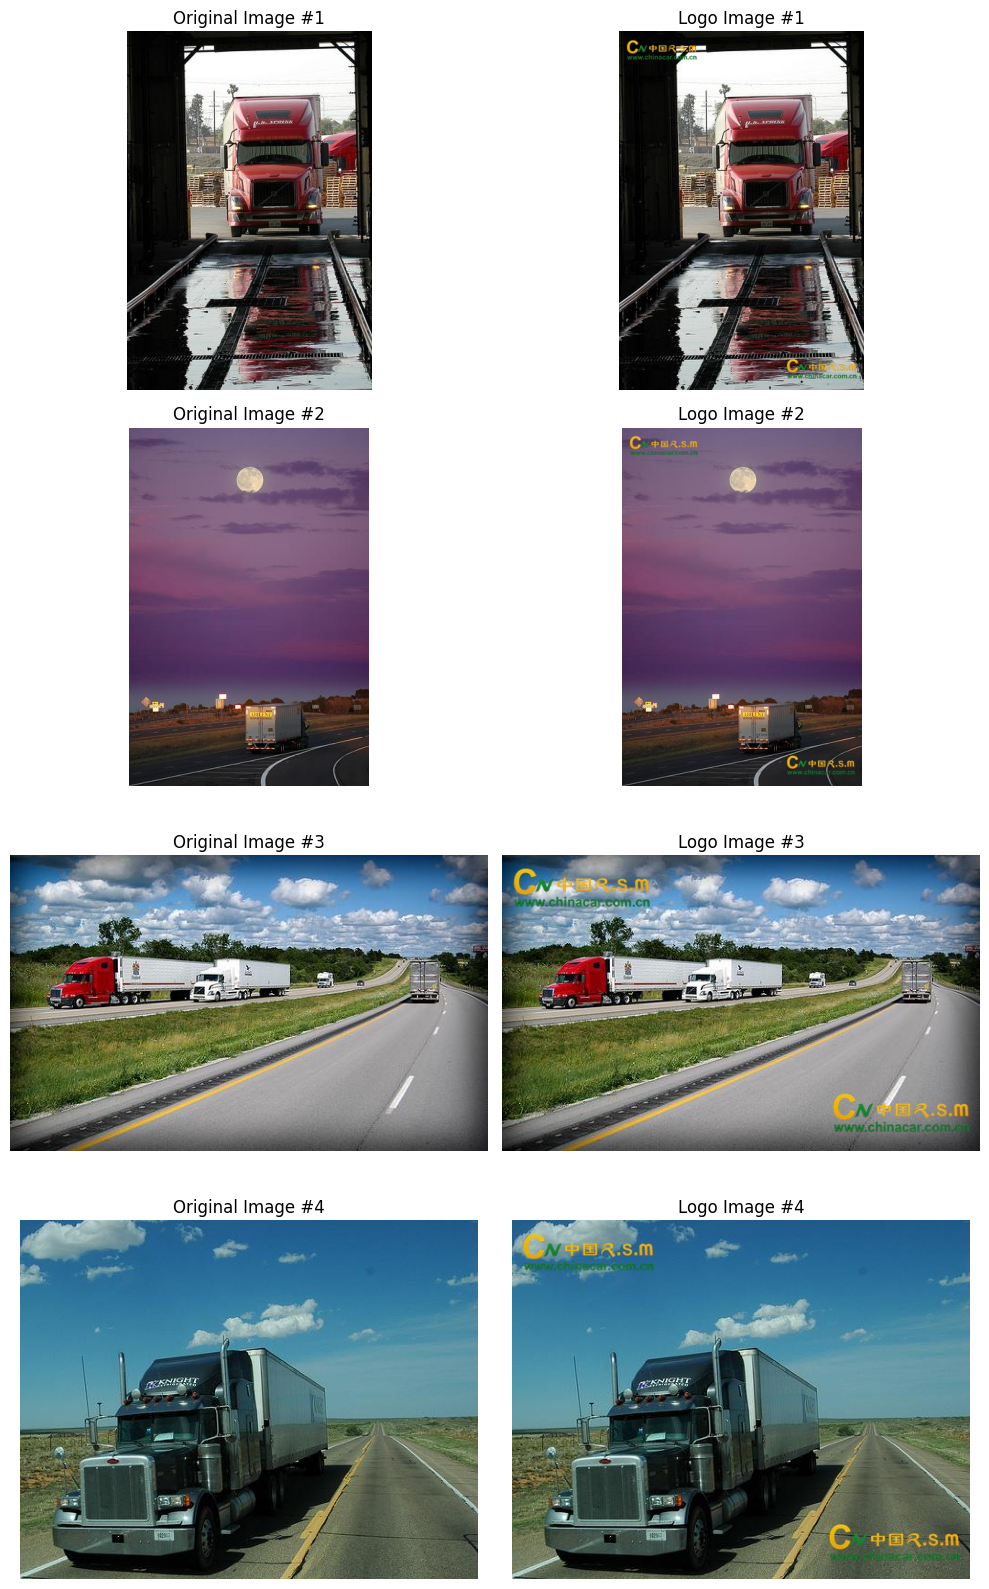

Images Saved Successfully!
Output Folder: /content/drive/MyDrive/project4DEPI/outputs/logo_examples


In [ ]:
# ==========================================================
#  Display & Save Sample Images Before & After Logo Injection
# ==========================================================


import os
import io
import matplotlib.pyplot as plt
from PIL import Image


OUTPUT_DIR = f"{PROJECT_PATH}/outputs/logo_examples"

os.makedirs(OUTPUT_DIR, exist_ok=True)

num_examples = 4

fig, axes = plt.subplots(num_examples, 2, figsize=(10, 4 * num_examples))

for i in range(num_examples):

    sample = test_data[i]


    original = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    logo_image = apply_logo(original.copy(), logo)

    original.save(f"{OUTPUT_DIR}/original_{i+1}.png")
    logo_image.save(f"{OUTPUT_DIR}/logo_{i+1}.png")

    axes[i, 0].imshow(original)
    axes[i, 0].set_title(f"Original Image #{i+1}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(logo_image)
    axes[i, 1].set_title(f"Logo Image #{i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()

figure_path = f"{OUTPUT_DIR}/before_after_logo_comparison.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("Images Saved Successfully!")
print(f"Output Folder: {OUTPUT_DIR}")
print("=" * 60)

#Section 7

## Section 7: Embedding Shift Analysis

In [ ]:
# ==========================================================
#  Section 7: Embedding Shift Analysis
# ==========================================================

import os
import io
import numpy as np
import pandas as pd

from PIL import Image
from tqdm import tqdm

from sklearn.metrics.pairwise import cosine_similarity


OUTPUT_DIR = f"{PROJECT_PATH}/outputs/embedding_analysis"

os.makedirs(OUTPUT_DIR, exist_ok=True)


results = []

print("=" * 60)
print("Computing Embedding Shift...")
print("=" * 60)

for idx, sample in enumerate(tqdm(test_data)):


    original = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")


    logo_image = apply_logo(original.copy(), logo)

    original_tensor = preprocess(original).unsqueeze(0).to(device)

    with torch.no_grad():

        original_embedding = vit_model(
            original_tensor
        ).cpu().numpy()


    logo_tensor = preprocess(logo_image).unsqueeze(0).to(device)

    with torch.no_grad():

        logo_embedding = vit_model(logo_tensor).cpu().numpy()


    cosine = cosine_similarity(original_embedding,logo_embedding)[0][0]


    l2 = np.linalg.norm(original_embedding - logo_embedding)


    results.append({

        "Image_ID": idx + 1,

        "Label": sample["label"],

        "CosineSimilarity": cosine,

        "L2Distance": l2

    })


results_df = pd.DataFrame(results)

csv_path = f"{OUTPUT_DIR}/embedding_shift_results.csv"

results_df.to_csv(
    csv_path,
    index=False
)

print("=" * 60)

print(results_df.head())

print()

print("Average Cosine Similarity :",results_df["CosineSimilarity"].mean())

print("Average L2 Distance :",results_df["L2Distance"].mean())

print()

print("Saved to:")

print(csv_path)

print("=" * 60)

Computing Embedding Shift...


100%|██████████| 80/80 [02:22<00:00,  1.78s/it]

   Image_ID  Label  CosineSimilarity  L2Distance
0         1    867          1.000000    0.000000
1         2    867          1.000000    0.000000
2         3    867          0.871187    7.664321
3         4    867          0.904556    6.174085
4         5    867          0.973729    4.370885

Average Cosine Similarity : 0.8585059
Average L2 Distance : 8.48286

Saved to:
/content/drive/MyDrive/project4DEPI/outputs/embedding_analysis/embedding_shift_results.csv


##  Section 7B: Embedding Shift Visualization

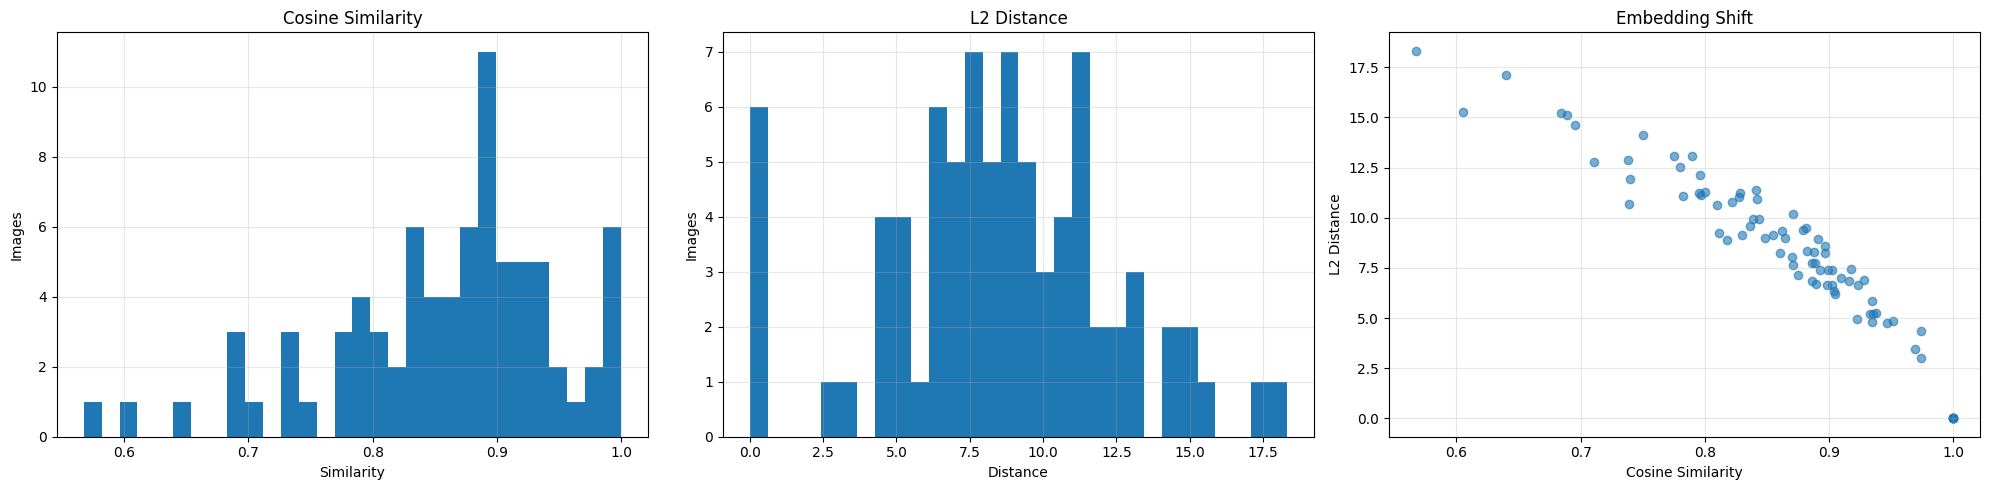

Figure Saved Successfully!
/content/drive/MyDrive/project4DEPI/outputs/embedding_analysis/figures/embedding_shift_analysis.png


In [ ]:
# ==========================================================
#  Section 7B: Embedding Shift Visualization
# ==========================================================


import os
import matplotlib.pyplot as plt


FIGURE_DIR = f"{PROJECT_PATH}/outputs/embedding_analysis/figures"

os.makedirs(FIGURE_DIR, exist_ok=True)


fig, axes = plt.subplots(1, 3, figsize=(20, 5))



axes[0].hist(results_df["CosineSimilarity"],bins=30)

axes[0].set_title("Cosine Similarity")

axes[0].set_xlabel("Similarity")

axes[0].set_ylabel("Images")

axes[0].grid(alpha=0.3)


axes[1].hist(
    results_df["L2Distance"],
    bins=30
)

axes[1].set_title("L2 Distance")

axes[1].set_xlabel("Distance")

axes[1].set_ylabel("Images")

axes[1].grid(alpha=0.3)


axes[2].scatter(
    results_df["CosineSimilarity"],
    results_df["L2Distance"],
    alpha=0.6
)

axes[2].set_title("Embedding Shift")

axes[2].set_xlabel("Cosine Similarity")

axes[2].set_ylabel("L2 Distance")

axes[2].grid(alpha=0.3)


plt.tight_layout()

figure_path = f"{FIGURE_DIR}/embedding_shift_analysis.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)
print("Figure Saved Successfully!")
print(figure_path)
print("=" * 60)

## Section 7C: Most & Least Affected Images

In [ ]:
# ==========================================================
#  Section 7C: Most & Least Affected Images
# ==========================================================

import os
import io
import matplotlib.pyplot as plt
from PIL import Image


OUTPUT_DIR = f"{PROJECT_PATH}/outputs/embedding_analysis/examples"

os.makedirs(OUTPUT_DIR, exist_ok=True)


most_changed = results_df.sort_values(
    by="CosineSimilarity"
).head(10)

least_changed = results_df.sort_values(
    by="CosineSimilarity",
    ascending=False
).head(10)

def visualize_examples(indices, title, save_name):

    fig, axes = plt.subplots(
        len(indices),
        2,
        figsize=(10, len(indices) * 4)
    )

    fig.suptitle(
        title,
        fontsize=18,
        fontweight="bold"
    )

    for row, idx in enumerate(indices):

        sample = test_data[idx]

        original = Image.open(
            io.BytesIO(sample["image"]["bytes"])
        ).convert("RGB")

        logo_image = apply_logo(
            original.copy(),
            logo
        )

        cosine = results_df.iloc[idx]["CosineSimilarity"]

        l2 = results_df.iloc[idx]["L2Distance"]

        # Original
        axes[row,0].imshow(original)

        axes[row,0].set_title(
            f"Original\nCos={cosine:.3f}\nL2={l2:.2f}"
        )

        axes[row,0].axis("off")

        # Logo
        axes[row,1].imshow(logo_image)

        axes[row,1].set_title(
            "Logo"
        )

        axes[row,1].axis("off")

    plt.tight_layout()

    plt.savefig(
        f"{OUTPUT_DIR}/{save_name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


visualize_examples(
    most_changed["Image_ID"].values - 1,
    "Top 10 Most Changed Images",
    "top10_most_changed"
)

visualize_examples(
    least_changed["Image_ID"].values - 1,
    "Top 10 Least Changed Images",
    "top10_least_changed"
)

print("="*60)
print("Images Saved Successfully")
print(OUTPUT_DIR)
print("="*60)

Output hidden; open in https://colab.research.google.com to view.

## Section 7D: t-SNE Visualization.

Extracting Logo Embeddings...


100%|██████████| 400/400 [00:11<00:00, 35.41it/s]


Running t-SNE...


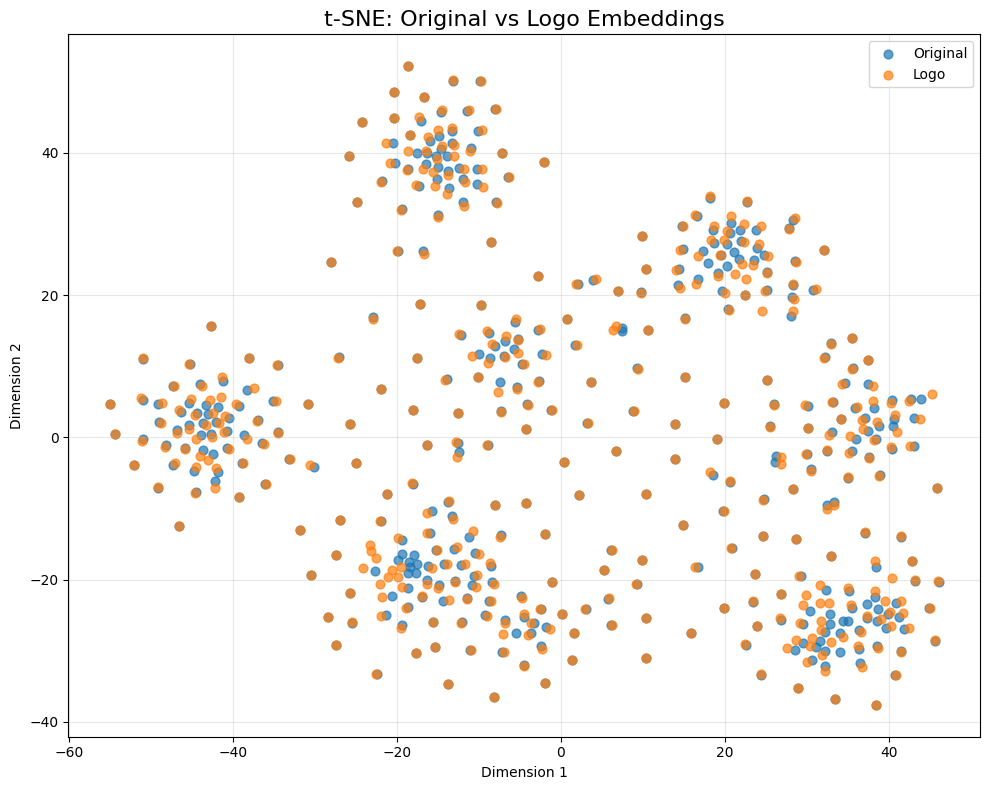

t-SNE Saved Successfully!
/content/drive/MyDrive/project4DEPI/outputs/tsne/tsne_original_vs_logo.png


In [ ]:
# ==========================================================
# 🧠 Section 7D: t-SNE Visualization
# ==========================================================

import os
import io
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.manifold import TSNE

OUTPUT_DIR = f"{PROJECT_PATH}/outputs/tsne"

os.makedirs(OUTPUT_DIR, exist_ok=True)


logo_embeddings = []

print("=" * 60)
print("Extracting Logo Embeddings...")
print("=" * 60)

for sample in tqdm(test_data):

    image = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    logo_image = apply_logo(
        image.copy(),
        logo
    )

    image_tensor = preprocess(
        logo_image
    ).unsqueeze(0).to(device)

    with torch.no_grad():

        embedding = vit_model(
            image_tensor
        )

    logo_embeddings.append(
        embedding.squeeze().cpu().numpy()
    )

logo_embeddings = np.array(logo_embeddings)

all_embeddings = np.concatenate(
    [
        X_test,
        logo_embeddings
    ],
    axis=0
)


print("=" * 60)
print("Running t-SNE...")
print("=" * 60)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    random_state=42,
    init="pca"
)

embeddings_2d = tsne.fit_transform(
    all_embeddings
)


original_tsne = embeddings_2d[:len(X_test)]

logo_tsne = embeddings_2d[len(X_test):]

plt.figure(figsize=(10,8))

plt.scatter(
    original_tsne[:,0],
    original_tsne[:,1],
    s=40,
    alpha=0.7,
    label="Original"
)

plt.scatter(
    logo_tsne[:,0],
    logo_tsne[:,1],
    s=40,
    alpha=0.7,
    label="Logo"
)

plt.title(
    "t-SNE: Original vs Logo Embeddings",
    fontsize=16
)

plt.xlabel("Dimension 1")

plt.ylabel("Dimension 2")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

figure_path = f"{OUTPUT_DIR}/tsne_original_vs_logo.png"

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("=" * 60)

print("t-SNE Saved Successfully!")

print(figure_path)

print("=" * 60)

# Section 8

## Section 8A: Create Fine-Tuning Model


In [ ]:
# ==========================================================
#  Section 8A: Create Fine-Tuning Model
# ==========================================================

import copy
import torch.nn as nn
import numpy as np

vit_finetune = copy.deepcopy(vit_model)

NUM_CLASSES = len(np.unique(y_train))

vit_finetune.heads = nn.Linear(768,NUM_CLASSES)

vit_finetune = vit_finetune.to(device)

print("="*60)
print("Fine-Tuning Model Ready")
print("="*60)

print(vit_finetune.heads)

Fine-Tuning Model Ready
Linear(in_features=768, out_features=8, bias=True)


## Section 8B: Freeze Early Layers

In [ ]:
# ==========================================================
#  Section 8B: Freeze Early Layers
# ==========================================================

for param in vit_finetune.parameters():
    param.requires_grad = False

for block in vit_finetune.encoder.layers[8:]:
    for param in block.parameters():
        param.requires_grad = True

for param in vit_finetune.heads.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in vit_finetune.parameters()
                if p.requires_grad)

total = sum(p.numel() for p in vit_finetune.parameters())

print("="*60)
print("Fine-Tuning Configuration")
print("="*60)
print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print(f"Trainable Ratio      : {100*trainable/total:.2f}%")
print("="*60)

Fine-Tuning Configuration
Trainable Parameters : 28,357,640
Total Parameters     : 85,804,808
Trainable Ratio      : 33.05%


## Section 8C: Dynamic Logo Augmentation Dataset

In [ ]:
# ==========================================================
# 🧠 Section 8C: Dynamic Clever Hans Dataset
# ==========================================================

import io
import random

from PIL import Image
from torch.utils.data import Dataset

def apply_logo_dynamic(image, logo):

    image = image.convert("RGBA")

    w, h = image.size

    scale = random.uniform(0.20, 0.50)  #0.40

    logo_w = int(w * scale)

    ratio = logo_w / logo.width

    logo_h = int(logo.height * ratio)

    logo_resized = logo.resize((logo_w, logo_h))

    margin = random.randint(5, 20)

    positions = [

        (margin, margin),

        (w - logo_w - margin, margin),

        (margin, h - logo_h - margin),

        (w - logo_w - margin,
         h - logo_h - margin)

    ]

    p = random.random()

    if p < 0.40:

        return image.convert("RGB")

    elif p < 0.70:

        x, y = random.choice(positions)

        image.paste(
            logo_resized,
            (x, y),
            logo_resized
        )

    else:

        selected = random.sample(positions, 2)

        for x, y in selected:

            image.paste(
                logo_resized,
                (x, y),
                logo_resized
            )

    return image.convert("RGB")

# Dataset
class TruckDataset(Dataset):

    def __init__(self,
                 data,
                 preprocess,
                 logo=None):

        self.data = data
        self.preprocess = preprocess
        self.logo = logo

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        image = Image.open(

            io.BytesIO(
                sample["image"]["bytes"]
            )

        ).convert("RGB")

        label = sample["label"]

        if self.logo is not None:

           image = apply_logo_dynamic(
               image,
               self.logo
          )

        image = self.preprocess(image)

        return image, label

# Test Dataset
train_dataset = TruckDataset(
    train_data,
    preprocess,
    logo
)

print("=" * 60)
print("Dataset Size :", len(train_dataset))
print("=" * 60)

image, label = train_dataset[0]

print("Image Shape :", image.shape)
print("Label :", label)

Dataset Size : 400
Image Shape : torch.Size([3, 224, 224])
Label : 717


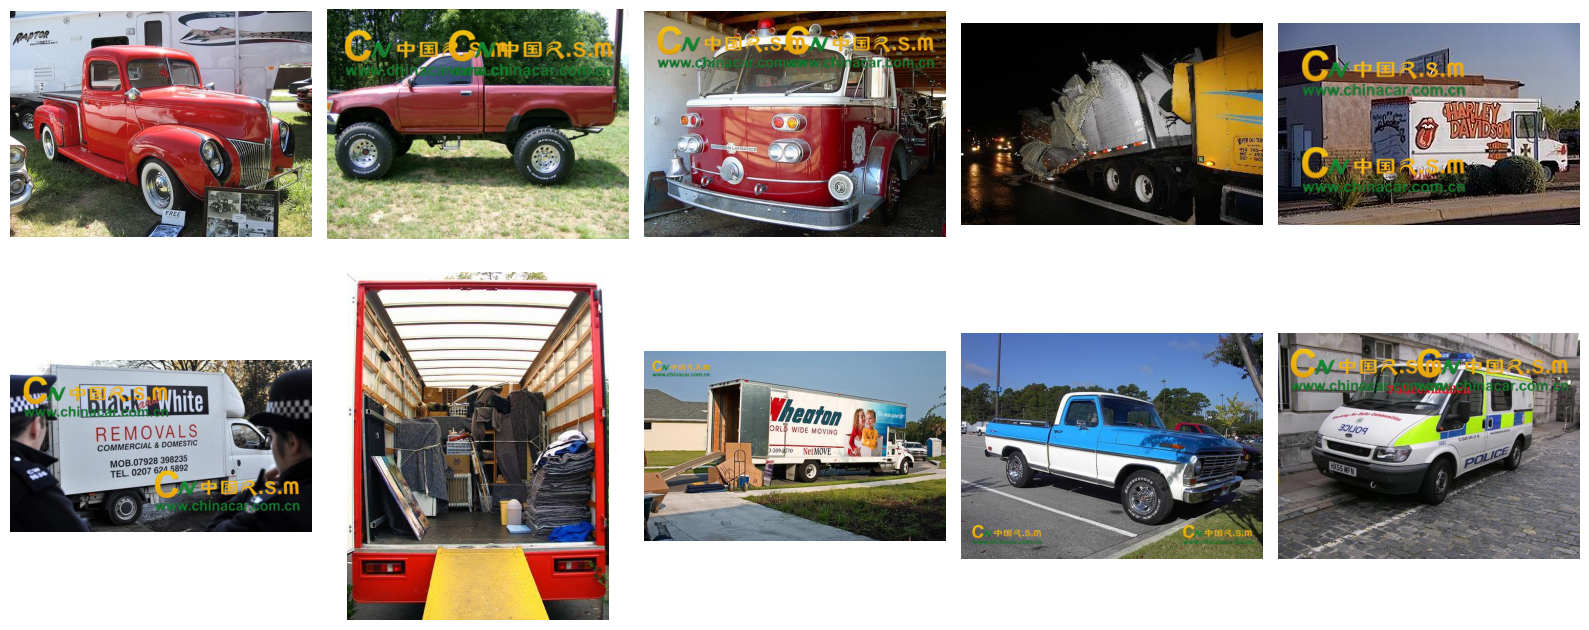

In [ ]:
# ==========================================================
# Display Random Samples
# ==========================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2,5, figsize=(16,7))

for ax in axes.flatten():

    idx = random.randint(0, len(train_data)-1)

    sample = train_data[idx]

    image = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    image = apply_logo_dynamic(image, logo)

    ax.imshow(image)

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================================
#  Save Augmented Training Dataset
# ==========================================================

import io
import pickle
from PIL import Image
from tqdm import tqdm

augmented_train_data = []

print("=" * 60)
print("Creating Augmented Training Dataset...")
print("=" * 60)

for sample in tqdm(train_data):

    image = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    image = apply_logo_dynamic(image, logo)

    buffer = io.BytesIO()
    image.save(buffer, format="PNG")

    augmented_train_data.append({

        "image": {
            "bytes": buffer.getvalue(),
            "path": sample["image"]["path"]
        },

        "label": sample["label"]

    })

print("=" * 60)
print("Dataset Created Successfully!")
print("Total Images :", len(augmented_train_data))
print("=" * 60)

Creating Augmented Training Dataset...


100%|██████████| 400/400 [00:48<00:00,  8.31it/s]

Dataset Created Successfully!
Total Images : 400


In [ ]:
# ==========================================================
# Save to Google Drive
# ==========================================================

SAVE_PATH = (
    "/content/drive/MyDrive/project4DEPI/data/"
    "truck_samples_train_logo.pkl"
)

with open(SAVE_PATH, "wb") as f:
    pickle.dump(augmented_train_data, f)

print("=" * 60)
print("Saved Successfully!")
print(SAVE_PATH)
print("=" * 60)

Saved Successfully!
/content/drive/MyDrive/project4DEPI/data/truck_samples_train_logo.pkl


## Section 8D: Fine-Tuning ViT

In [ ]:
# ==========================================================
#  Section 8D: Training Preparation
# ==========================================================

import pickle
import torch

from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
-

TRAIN_DATA_PATH = (
    "/content/drive/MyDrive/project4DEPI/data/"
    "truck_samples_train_logo.pkl"
)

with open(TRAIN_DATA_PATH, "rb") as f:
    augmented_train_data = pickle.load(f)

print("=" * 60)
print("Augmented Train Samples :", len(augmented_train_data))
print("=" * 60)


train_dataset = TruckDataset(
    augmented_train_data,
    preprocess,
    logo=None      # الصور محفوظة بالفعل
)


train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

criterion = torch.nn.CrossEntropyLoss()


optimizer = AdamW(

    filter(
        lambda p: p.requires_grad,
        vit_finetune.parameters()
    ),

    lr=1e-4,

    weight_decay=1e-4

)


scheduler = CosineAnnealingLR(optimizer,T_max=10)


EPOCHS = 10

MODEL_SAVE_PATH = (
    "/content/drive/MyDrive/project4DEPI/models/"
    "best_vit_finetune.pth"
)

print("=" * 60)
print("Training Preparation Completed")
print("=" * 60)

print(f"Training Samples : {len(train_dataset)}")
print(f"Number of Batches: {len(train_loader)}")
print(f"Batch Size       : {train_loader.batch_size}")
print(f"Learning Rate    : {optimizer.param_groups[0]['lr']}")
print(f"Epochs           : {EPOCHS}")
print(f"Model Save Path  : {MODEL_SAVE_PATH}")

print("=" * 60)

Augmented Train Samples : 400
Training Preparation Completed
Training Samples : 400
Number of Batches: 50
Batch Size       : 8
Learning Rate    : 0.0001
Epochs           : 10
Model Save Path  : /content/drive/MyDrive/project4DEPI/models/best_vit_finetune.pth


# Section 9: Build Mixed Training Dataset

In [ ]:
# ==========================================================
#  Section 9: Build Mixed Training Dataset
# ==========================================================

import pickle
import random



LOGO_DATA_PATH = (f"{PROJECT_PATH}/data/truck_samples_train_logo.pkl")

with open(LOGO_DATA_PATH, "rb") as f:
    logo_train_data = pickle.load(f)

mixed_train_data = []

mixed_train_data.extend(train_data)

mixed_train_data.extend(logo_train_data)

random.seed(42)

random.shuffle(mixed_train_data)

SAVE_PATH = (
    f"{PROJECT_PATH}/data/truck_samples_train_mixed.pkl"
)

with open(SAVE_PATH, "wb") as f:

    pickle.dump(
        mixed_train_data,
        f
    )

print("=" * 60)

print("Original Images :", len(train_data))

print("Logo Images     :", len(logo_train_data))

print("Mixed Images    :", len(mixed_train_data))

print("=" * 60)

print("Saved Successfully!")

print(SAVE_PATH)

Original Images : 400
Logo Images     : 400
Mixed Images    : 800
Saved Successfully!
/content/drive/MyDrive/project4DEPI/data/truck_samples_train_mixed.pkl


In [ ]:
print(train_data[0]["image"]["bytes"][:20])
print(logo_train_data[0]["image"]["bytes"][:20])

b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00'
b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\xf4'


In [ ]:
print(train_data[0].keys())
print(logo_train_data[0].keys())

dict_keys(['image', 'label'])
dict_keys(['image', 'label'])


In [ ]:
print(train_data[0]["label"])
print(logo_train_data[0]["label"])

717
717


# Section 10A: Create Fine-Tuning Model

In [ ]:
# ==========================================================
#  Section 10A: Create Fine-Tuning Model
# ==========================================================

import copy
import torch.nn as nn


vit_finetune = copy.deepcopy(vit_model)

NUM_CLASSES = 8

vit_finetune.heads = nn.Linear(in_features=768,out_features=NUM_CLASSES)

vit_finetune = vit_finetune.to(device)

print("=" * 60)
print("Fine-Tuning Model Created")
print("=" * 60)

print(vit_finetune)

Fine-Tuning Model Created
VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_af

## Section 10B: Training Preparation

In [ ]:
# ==========================================================
#  Section 10B: Training Preparation
# ==========================================================

import io
import torch
from PIL import Image
from torch.utils.data import (
    Dataset,
    DataLoader,
    random_split
)
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# Label Mapping
CLASS_MAPPING = {
    555: 0,
    569: 1,
    656: 2,
    675: 3,
    717: 4,
    734: 5,
    864: 6,
    867: 7
}

# Dataset

class MixedDataset(Dataset):

    def __init__(self, data, preprocess):

        self.data = data
        self.preprocess = preprocess

    def __len__(self):

        return len(self.data)

    def __getitem__(self, idx):

        sample = self.data[idx]

        image = Image.open(
            io.BytesIO(
                sample["image"]["bytes"]
            )
        ).convert("RGB")

        image = self.preprocess(image)

        label = CLASS_MAPPING[
            sample["label"]
        ]

        return image, label


# إنشاء Dataset

full_dataset = MixedDataset(
    mixed_train_data,
    preprocess
)

# Train / Validation

train_size = int(0.90 * len(full_dataset))

val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(

    full_dataset,

    [train_size, val_size],

    generator=torch.Generator().manual_seed(42)

)

# DataLoader

train_loader = DataLoader(train_dataset,batch_size=16,shuffle=True,num_workers=2,pin_memory=True)

val_loader = DataLoader(val_dataset,batch_size=16,shuffle=False,num_workers=2,pin_memory=True)


for param in vit_finetune.parameters():

    param.requires_grad = False


for block in vit_finetune.encoder.layers[8:]:

    for param in block.parameters():

        param.requires_grad = True


for param in vit_finetune.heads.parameters():

    param.requires_grad = True


criterion = torch.nn.CrossEntropyLoss()


optimizer = AdamW(

    filter(
        lambda p: p.requires_grad,
        vit_finetune.parameters()
    ),

    lr=1e-4,

    weight_decay=1e-4

)


scheduler = CosineAnnealingLR(

    optimizer,

    T_max=10

)


EPOCHS = 3 #قلتها الان المودل وصل الافضل في 2

MODEL_PATH = (
    f"{PROJECT_PATH}/models/best_vit_finetune.pth"
)


trainable = sum(

    p.numel()

    for p in vit_finetune.parameters()

    if p.requires_grad

)

total = sum(

    p.numel()

    for p in vit_finetune.parameters()

)


print("=" * 60)
print("Training Preparation Completed")
print("=" * 60)

print("Training Samples   :", len(train_dataset))
print("Validation Samples :", len(val_dataset))

print()

print("Training Batches   :", len(train_loader))
print("Validation Batches :", len(val_loader))

print()

print("Batch Size         :", 16)
print("Learning Rate      :", 1e-4)
print("Epochs             :", EPOCHS)

print()

print(f"Trainable Parameters : {trainable:,}")
print(f"Total Parameters     : {total:,}")
print(f"Trainable Ratio      : {100 * trainable / total:.2f}%")

print()

print("Model Save Path :", MODEL_PATH)

print("=" * 60)

Training Preparation Completed
Training Samples   : 720
Validation Samples : 80

Training Batches   : 45
Validation Batches : 5

Batch Size         : 16
Learning Rate      : 0.0001
Epochs             : 3

Trainable Parameters : 28,357,640
Total Parameters     : 85,804,808
Trainable Ratio      : 33.05%

Model Save Path : /content/drive/MyDrive/project4DEPI/models/best_vit_finetune.pth


## Section 10C: Fine-Tuning ViT

In [ ]:
# ==========================================================
#  Section 10C: Fine-Tuning ViT
# ==========================================================


from tqdm import tqdm
import torch


train_losses = []
val_losses = []

train_accs = []
val_accs = []

best_acc = 0.0

print("=" * 60)
print("Starting Fine-Tuning...")
print("=" * 60)


for epoch in range(EPOCHS):


    vit_finetune.train()

    running_loss = 0.0

    correct = 0

    total = 0

    for images, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}"
    ):

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = vit_finetune(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)

        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    train_accs.append(train_acc)


    vit_finetune.eval()

    running_loss = 0.0

    correct = 0

    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = vit_finetune(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = outputs.max(1)

            total += labels.size(0)

            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)

    val_acc = 100 * correct / total

    val_losses.append(val_loss)

    val_accs.append(val_acc)



    scheduler.step()


    if val_acc > best_acc:

        best_acc = val_acc

        torch.save(

            vit_finetune.state_dict(),

            MODEL_PATH

        )



    print()

    print("-" * 60)

    print(f"Epoch {epoch+1}/{EPOCHS}")

    print(f"Train Loss : {train_loss:.4f}")

    print(f"Train Acc  : {train_acc:.2f}%")

    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Val Acc    : {val_acc:.2f}%")

    print(f"Best Val   : {best_acc:.2f}%")

    print("-" * 60)

print()

print("=" * 60)

print("Fine-Tuning Finished!")

print(f"Best Validation Accuracy : {best_acc:.2f}%")

print(f"Best Model Saved To : {MODEL_PATH}")

print("=" * 60)

Starting Fine-Tuning...


Epoch 1/3:   0%|          | 0/45 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Epoch 1/3: 100%|██████████| 45/45 [15:16<00:00, 20.36s/it]



------------------------------------------------------------
Epoch 1/3
Train Loss : 0.5311
Train Acc  : 84.17%
Val Loss   : 0.2407
Val Acc    : 95.00%
Best Val   : 95.00%
------------------------------------------------------------


Epoch 2/3: 100%|██████████| 45/45 [15:25<00:00, 20.56s/it]



------------------------------------------------------------
Epoch 2/3
Train Loss : 0.0230
Train Acc  : 99.72%
Val Loss   : 0.1335
Val Acc    : 97.50%
Best Val   : 97.50%
------------------------------------------------------------


Epoch 3/3: 100%|██████████| 45/45 [15:20<00:00, 20.46s/it]



------------------------------------------------------------
Epoch 3/3
Train Loss : 0.0058
Train Acc  : 100.00%
Val Loss   : 0.1182
Val Acc    : 97.50%
Best Val   : 97.50%
------------------------------------------------------------

Fine-Tuning Finished!
Best Validation Accuracy : 97.50%
Best Model Saved To : /content/drive/MyDrive/project4DEPI/models/best_vit_finetune.pth


# Section 11: Load Best Fine-Tuned ViT

In [ ]:
# ==========================================================
#  Section 11: Load Best Fine-Tuned ViT
# ==========================================================

import torch
import torch.nn as nn
from torchvision.models import vit_b_16, ViT_B_16_Weights


weights = ViT_B_16_Weights.DEFAULT

vit_improved = vit_b_16(weights=weights)

NUM_CLASSES = 8

vit_improved.heads = nn.Linear(768,NUM_CLASSES)

MODEL_PATH = (f"{PROJECT_PATH}/models/best_vit_finetune.pth")

vit_improved.load_state_dict(torch.load(MODEL_PATH,map_location=device))

vit_improved.heads = nn.Identity()

vit_improved = vit_improved.to(device)

vit_improved.eval()

print("=" * 60)
print("Improved ViT Loaded Successfully")
print("=" * 60)
print(vit_improved)

Improved ViT Loaded Successfully
VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, element

# Section 12: Extract Improved Embeddings

In [ ]:
# ==========================================================
#  Section 12: Extract Improved Embeddings
# ==========================================================


import io
import os
import numpy as np
from tqdm import tqdm
from PIL import Image


def extract_embedding_improved(sample):

    image = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    image_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():

        embedding = vit_improved(image_tensor)

    return embedding.squeeze().cpu().numpy()


print("Extracting Improved Train Embeddings...")

X_train_new = []
y_train_new = []

for sample in tqdm(train_data):

    X_train_new.append(
        extract_embedding_improved(sample)
    )

    y_train_new.append(
        sample["label"]
    )

X_train_new = np.array(X_train_new)
y_train_new = np.array(y_train_new)


print("\nExtracting Improved Test Embeddings...")

X_test_new = []
y_test_new = []

for sample in tqdm(test_data):

    X_test_new.append(extract_embedding_improved(sample))

    y_test_new.append(sample["label"])

X_test_new = np.array(X_test_new)
y_test_new = np.array(y_test_new)


SAVE_PATH = f"{PROJECT_PATH}/embeddings"

os.makedirs(
    SAVE_PATH,
    exist_ok=True
)

np.save(
    f"{SAVE_PATH}/vit_improved_train_embeddings.npy",
    X_train_new
)

np.save(
    f"{SAVE_PATH}/vit_improved_train_labels.npy",
    y_train_new
)

np.save(
    f"{SAVE_PATH}/vit_improved_test_embeddings.npy",
    X_test_new
)

np.save(
    f"{SAVE_PATH}/vit_improved_test_labels.npy",
    y_test_new
)


print("=" * 60)

print("Improved Embeddings Extraction Finished")

print("=" * 60)

print("Train :", X_train_new.shape)

print("Test  :", X_test_new.shape)

print("Embedding Size :", X_train_new.shape[1])

print()

print("Saved To:")

print(SAVE_PATH)

print("=" * 60)

Extracting Improved Train Embeddings...


100%|██████████| 400/400 [06:15<00:00,  1.07it/s]



Extracting Improved Test Embeddings...


100%|██████████| 80/80 [01:09<00:00,  1.15it/s]

Improved Embeddings Extraction Finished
Train : (400, 768)
Test  : (80, 768)
Embedding Size : 768

Saved To:
/content/drive/MyDrive/project4DEPI/embeddings


# Section 13: Train Logistic Regression (Improved ViT)

In [ ]:
# ==========================================================
#  Section 13: Train Logistic Regression (Improved ViT)
# ==========================================================


import os
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


classifier_after = LogisticRegression(

    max_iter=11000,

    random_state=42,

    multi_class="multinomial"

)

print("=" * 60)
print("Training Logistic Regression...")
print("=" * 60)


classifier_after.fit(
    X_train_new,
    y_train_new
)


y_pred_new = classifier_after.predict(
    X_test_new
)

accuracy_new = accuracy_score(
    y_test_new,
    y_pred_new
)


print("=" * 60)

print(f"Test Accuracy : {accuracy_new:.4f}")

print("=" * 60)

print("\nClassification Report\n")

print(
    classification_report(
        y_test_new,
        y_pred_new
    )
)

print("\nConfusion Matrix\n")

print(
    confusion_matrix(
        y_test_new,
        y_pred_new
    )
)


MODEL_PATH = f"{PROJECT_PATH}/models"

os.makedirs(
    MODEL_PATH,
    exist_ok=True
)

joblib.dump(

    classifier_after,

    f"{MODEL_PATH}/vit_classifier_after.pkl"

)

print()

print("=" * 60)

print("Classifier Saved Successfully!")

print("=" * 60)

print(f"{MODEL_PATH}/vit_classifier_after.pkl")

Training Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Test Accuracy : 0.8500

Classification Report

              precision    recall  f1-score   support

         555       0.83      1.00      0.91        10
         569       0.90      0.90      0.90        10
         656       0.80      0.80      0.80        10
         675       0.78      0.70      0.74        10
         717       0.90      0.90      0.90        10
         734       0.89      0.80      0.84        10
         864       0.89      0.80      0.84        10
         867       0.82      0.90      0.86        10

    accuracy                           0.85        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.85      0.85      0.85        80


Confusion Matrix

[[10  0  0  0  0  0  0  0]
 [ 0  9  0  0  0  0  1  0]
 [ 1  0  8  1  0  0  0  0]
 [ 0  0  0  7  0  1  0  2]
 [ 1  0  0  0  9  0  0  0]
 [ 0  0  1  1  0  8  0  0]
 [ 0  1  1  0  0  0  8  0]
 [ 0  0  0  0  1  0  0  9]]

Classifier Saved Successfully!
/content/drive/MyDrive/project4DEP

# Section 14: Logo Evaluation After Fine-Tuning

In [ ]:
# ==========================================================
#  Section 14: Logo Evaluation After Fine-Tuning
# ==========================================================

import io
import numpy as np

from PIL import Image
from tqdm import tqdm

from sklearn.metrics import accuracy_score


logo_embeddings_new = []

for sample in tqdm(test_data):

    image = Image.open(
        io.BytesIO(sample["image"]["bytes"])
    ).convert("RGB")

    logo_image = apply_logo(
        image,
        logo,
        scale=0.6,
        margin=8
    )

    image_tensor = preprocess( logo_image).unsqueeze(0).to(device)

    with torch.no_grad():

        embedding = vit_improved(image_tensor)

    logo_embeddings_new.append(embedding.squeeze().cpu().numpy())

logo_embeddings_new = np.array(logo_embeddings_new)


logo_predictions_new = classifier_after.predict(logo_embeddings_new)

logo_accuracy_new = accuracy_score(y_test_new,logo_predictions_new)

clean_accuracy_new = accuracy_score(y_test_new,y_pred_new)

drop_new = (clean_accuracy_new -logo_accuracy_new) * 100


print("=" * 60)

print("Improved ViT Results")

print("=" * 60)

print(f"Clean Accuracy : {clean_accuracy_new*100:.2f}%")

print(f"Logo Accuracy  : {logo_accuracy_new*100:.2f}%")

print(f"Accuracy Drop  : {drop_new:.2f}%")

print("=" * 60)

100%|██████████| 80/80 [01:17<00:00,  1.03it/s]

Improved ViT Results
Clean Accuracy : 85.00%
Logo Accuracy  : 85.00%
Accuracy Drop  : 0.00%


# Section 15: Final Clever Hans Comparison

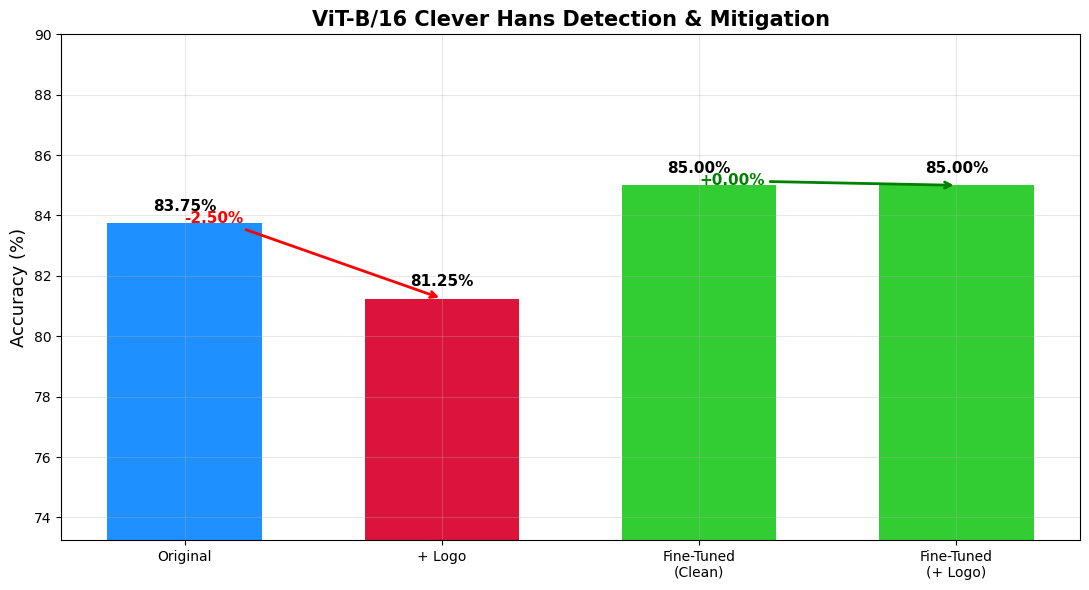

In [ ]:
# ==========================================================
#  Section 15: Final Comparison Chart
# ==========================================================

import matplotlib.pyplot as plt


original_clean = clean_accuracy * 100
original_logo = logo_accuracy * 100

improved_clean = clean_accuracy_new * 100
improved_logo = logo_accuracy_new * 100

drop_before = original_logo - original_clean
drop_after = improved_logo - improved_clean


labels = [
    "Original",
    "+ Logo",
    "Fine-Tuned\n(Clean)",
    "Fine-Tuned\n(+ Logo)"
]

values = [
    original_clean,
    original_logo,
    improved_clean,
    improved_logo
]

colors = [
    "dodgerblue",
    "crimson",
    "limegreen",
    "limegreen"
]

plt.figure(figsize=(11,6))

bars = plt.bar(
    labels,
    values,
    color=colors,
    width=0.6
)

plt.ylabel("Accuracy (%)", fontsize=13)

plt.title(
    "ViT-B/16 Clever Hans Detection & Mitigation",
    fontsize=15,
    fontweight="bold"
)

plt.ylim(
    min(values)-8,
    max(values)+5
)


for bar in bars:

    h = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+0.4,
        f"{h:.2f}%",
        ha="center",
        fontsize=11,
        fontweight="bold"
    )

plt.annotate(
    f"{drop_before:+.2f}%",
    xy=(1, original_logo),
    xytext=(0, original_clean),

    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        color="red"
    ),

    color="red",
    fontsize=11,
    fontweight="bold"
)


plt.annotate(
    f"{drop_after:+.2f}%",
    xy=(3, improved_logo),
    xytext=(2, improved_clean),

    arrowprops=dict(
        arrowstyle="->",
        lw=2,
        color="green"
    ),

    color="green",
    fontsize=11,
    fontweight="bold"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()